In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)


/opt/anaconda3/envs/rama-shap/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
train_df = pd.read_csv("/Users/kongphopkaochot/Desktop/Senior_Project/Practical Datascience/week15/TRAIN_DATASET.csv")
test_df = pd.read_csv("/Users/kongphopkaochot/Desktop/Senior_Project/Practical Datascience/week15/TEST_DATASET.csv")


In [3]:
X_train = train_df.drop(columns=["appendicitis", "Aggravation"])
y_train = train_df["appendicitis"]

X_test = test_df.drop(columns=["appendicitis", "Aggravation"])
y_test = test_df["appendicitis"]

In [4]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

acc_scores = []
f1_scores = []

for train_idx, val_idx in kf.split(X_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model = LogisticRegression(max_iter=1000)
    model.fit(X_tr, y_tr)

    y_pred = model.predict(X_val)

    acc_scores.append(accuracy_score(y_val, y_pred))
    f1_scores.append(f1_score(y_val, y_pred))

print("K-Fold Accuracy:", np.mean(acc_scores))
print("K-Fold F1:", np.mean(f1_scores))

K-Fold Accuracy: 0.758
K-Fold F1: 0.8374241825938423


In [5]:
final_model_no_Aggravation = LogisticRegression(max_iter=1000)
final_model_no_Aggravation.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [6]:
y_pred_test = final_model_no_Aggravation.predict(X_test)
y_prob_test = final_model_no_Aggravation.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_test))
print("AUC:", roc_auc_score(y_test, y_prob_test))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.64      0.43      0.51       110
           1       0.79      0.90      0.84       266

    accuracy                           0.76       376
   macro avg       0.72      0.66      0.68       376
weighted avg       0.75      0.76      0.75       376

AUC: 0.7565276828434722
Confusion Matrix:
[[ 47  63]
 [ 26 240]]


In [7]:
intercept = final_model_no_Aggravation.intercept_[0]
coefficients = final_model_no_Aggravation.coef_[0]
features = X_train.columns

print("\n=== Logistic Regression Result ไม่มี Aggravation ===")
print(f"Intercept: {intercept:.4f}")
print("-" * 45)

for name, coef in zip(features, coefficients):
    print(f"Weight of {name:15}: {coef: .4f}")

print("-" * 45)

equation = f"Logit (z) = {intercept:.4f}"

for name, coef in zip(features, coefficients):
    sign = "+" if coef >= 0 else "-"
    equation += f" {sign} ({abs(coef):.4f} * {name})"

print(equation)


=== Logistic Regression Result ไม่มี Aggravation ===
Intercept: -1.2504
---------------------------------------------
Weight of Progression    :  0.6478
Weight of Migration      : -0.0303
Weight of TEMP           : -0.7692
Weight of Rebound        :  1.1560
Weight of WBC            :  0.9045
Weight of Neut           :  1.1775
---------------------------------------------
Logit (z) = -1.2504 + (0.6478 * Progression) - (0.0303 * Migration) - (0.7692 * TEMP) + (1.1560 * Rebound) + (0.9045 * WBC) + (1.1775 * Neut)


Progression 0.21395673863496362
Migration 0.0820547361415827
TEMP -0.005650016213261255
Rebound 0.2917212450886293
WBC 0.30821891416093444
Neut 0.3058314547201093


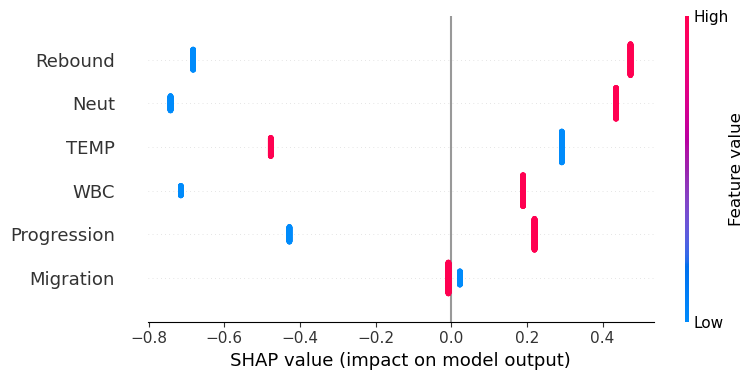

In [8]:
for col in X_train.columns:
    corr = train_df[[col, "appendicitis"]].corr().iloc[0, 1]
    print(col, corr)

# =========================
# 8) SHAP
# =========================
explainer = shap.Explainer(final_model_no_Aggravation, X_train)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)


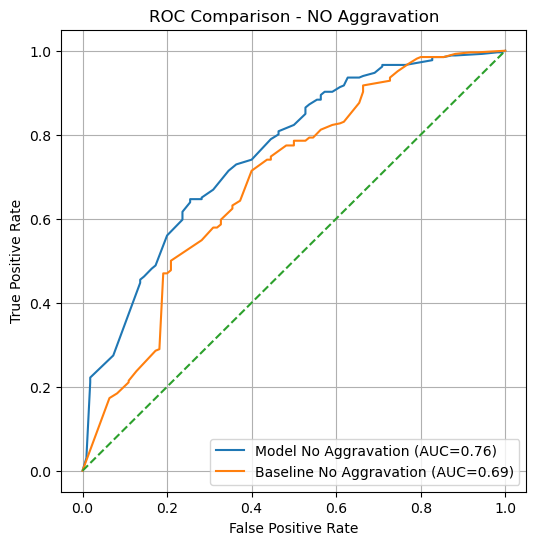

In [9]:

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# MODEL no Aggravation ใช้ X_test
y_prob_model_no_Aggravation = final_model_no_Aggravation.predict_proba(X_test)[:, 1]

# DOCTOR equation no Aggravation
Baseline_z_no_Aggravation = (
    -3.37
    + 1.04 * X_test["Progression"]
    + 0.80 * X_test["Migration"]
    # + 0.78 * X_test["Aggravation"]
    + 1.64 * X_test["TEMP"]
    + 1.53 * X_test["Rebound"]
    + 0.91 * X_test["WBC"]
    + 0.69 * X_test["Neut"]
)

Baseline_prob_no_Aggravation = sigmoid(Baseline_z_no_Aggravation)

# ROC + AUC
fpr_model, tpr_model, _ = roc_curve(y_test, y_prob_model_no_Aggravation)
auc_model = roc_auc_score(y_test, y_prob_model_no_Aggravation)

fpr_doc, tpr_doc, _ = roc_curve(y_test, Baseline_prob_no_Aggravation)
auc_doc = roc_auc_score(y_test, Baseline_prob_no_Aggravation)

plt.figure(figsize=(6, 6))
plt.plot(fpr_model, tpr_model, label=f"Model No Aggravation (AUC={auc_model:.2f})")
plt.plot(fpr_doc, tpr_doc, label=f"Baseline No Aggravation (AUC={auc_doc:.2f})")
plt.plot([0, 1], [0, 1], "--")

plt.title("ROC Comparison - NO Aggravation")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()